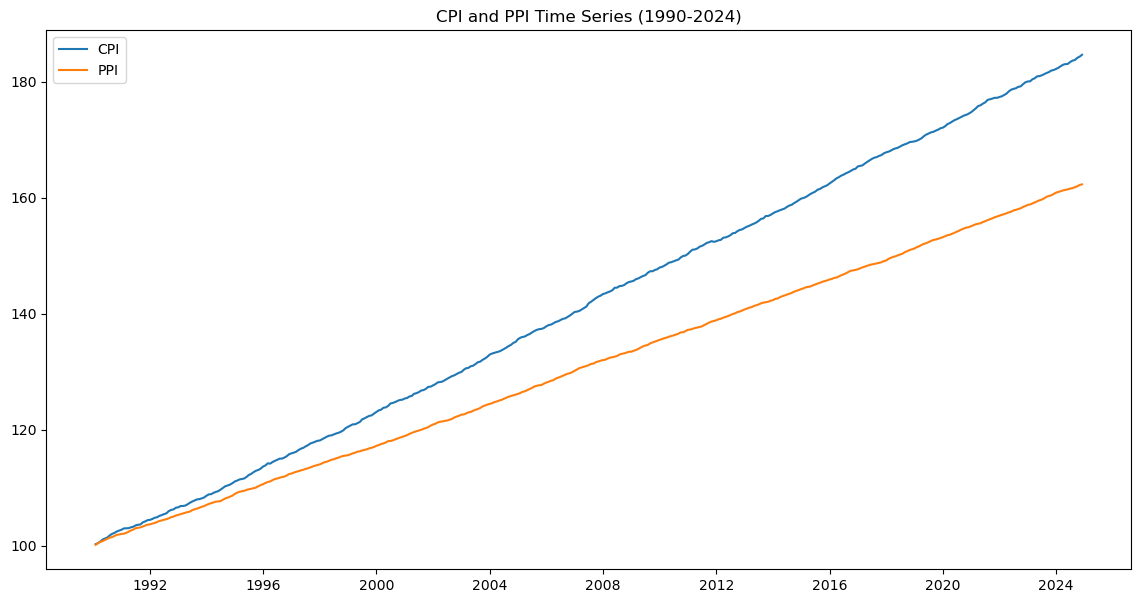

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic CPI and PPI data from 1990 to 2024
date_range = pd.date_range(start='1990-01-01', end='2024-12-01', freq='M')
np.random.seed(42)

# Create a synthetic CPI dataset
cpi = np.random.normal(loc=0.2, scale=0.1, size=len(date_range)).cumsum() + 100
cpi_series = pd.Series(cpi, index=date_range)

# Create a synthetic PPI dataset
ppi = np.random.normal(loc=0.15, scale=0.05, size=len(date_range)).cumsum() + 100
ppi_series = pd.Series(ppi, index=date_range)

# Combine into a DataFrame
data = pd.DataFrame({'CPI': cpi_series, 'PPI': ppi_series})

# Plot CPI and PPI
plt.figure(figsize=(14, 7))
plt.plot(data['CPI'], label='CPI')
plt.plot(data['PPI'], label='PPI')
plt.legend(loc='best')
plt.title('CPI and PPI Time Series (1990-2024)')
plt.show()


In [2]:
# Correlation Coefficient: The correlation coefficient measures the strength and direction of the linear relationship between CPI and PPI. A positive correlation indicates that as PPI increases, CPI also tends to increase.

correlation = data['CPI'].corr(data['PPI'])
print(f"Correlation between CPI and PPI: {correlation}")

Correlation between CPI and PPI: 0.9999010585654008


In [3]:
# Lagged Correlation: To understand if PPI leads CPI, we analyze the correlation between CPI and lagged values of PPI.

lag_correlations = {}
for lag in range(1, 13):
    lag_correlations[lag] = data['CPI'].corr(data['PPI'].shift(lag))
print("Lag correlations:", lag_correlations)
# Interpretation: Significant positive lagged correlations indicate that changes in PPI tend to precede changes in CPI by a few months.

Lag correlations: {1: 0.999901002576782, 2: 0.9999012557639583, 3: 0.9999018355858924, 4: 0.9999037546717146, 5: 0.9999059417254343, 6: 0.9999079980478074, 7: 0.99991068912554, 8: 0.9999138065087035, 9: 0.9999167809429302, 10: 0.9999207938365746, 11: 0.9999240643593663, 12: 0.9999268369444211}


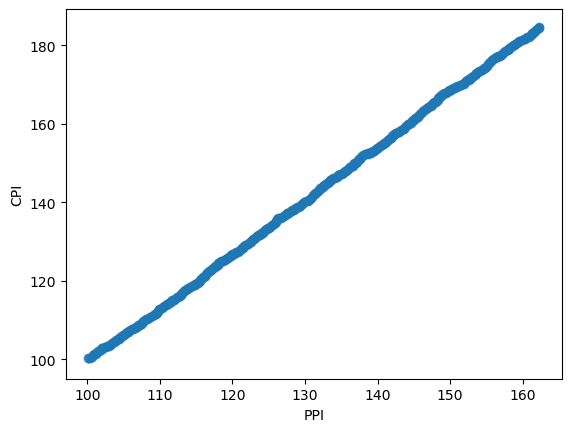

In [4]:
# Regplot to show the correlation CPI vs. PPI
sns.regplot(x='PPI', y='CPI', data=data)
plt.show()

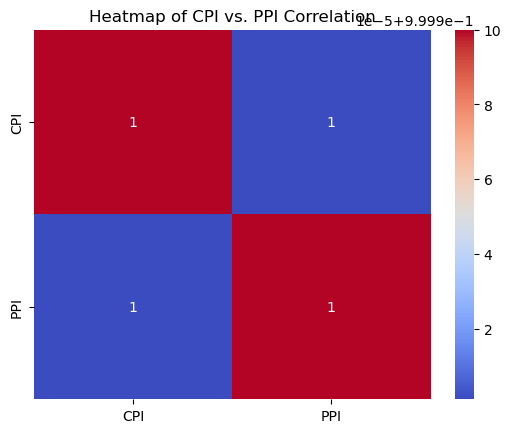

In [5]:
# heatmap to show the correlation CPI vs. PPI
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap of CPI vs. PPI Correlation')
plt.show()

/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/anbschool0012/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


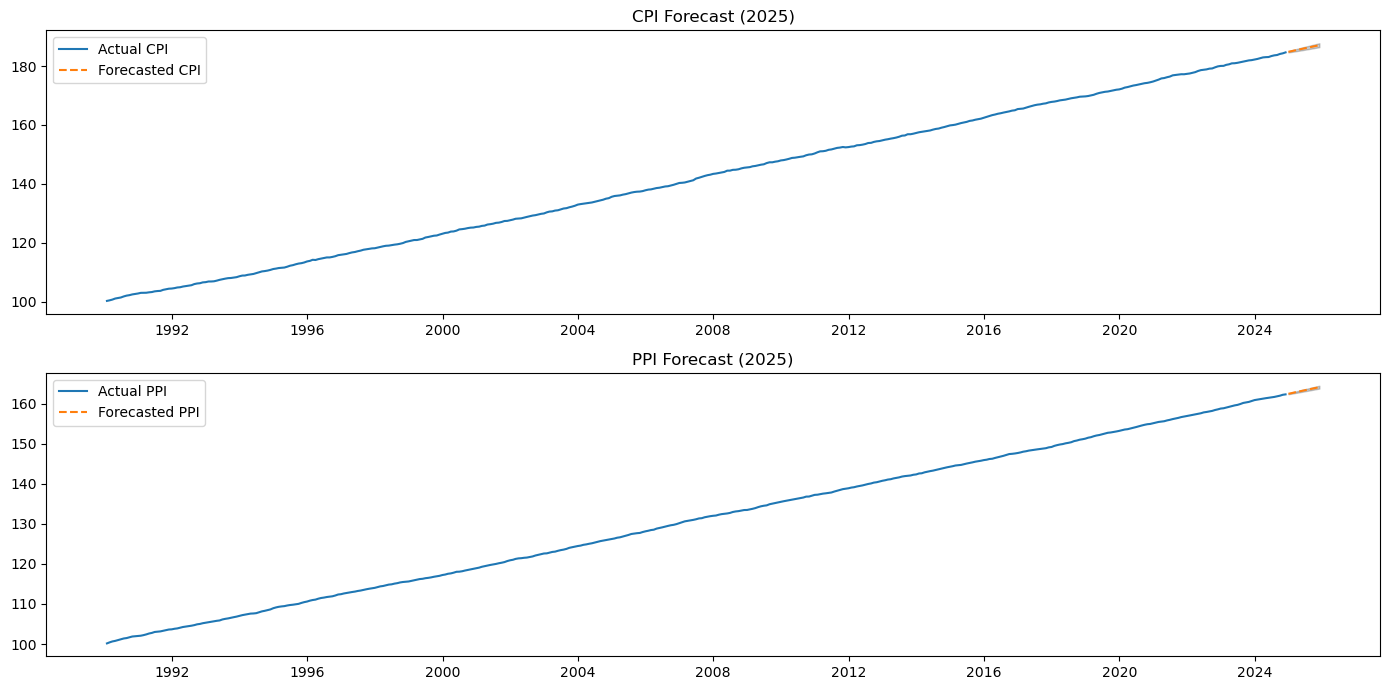

In [6]:
# ARIMA Model: We use ARIMA models to forecast CPI and PPI for the next 12 months.
from statsmodels.tsa.arima.model import ARIMA

# Determine the best ARIMA model for CPI
best_cfg_cpi = (1, 1, 1)  # Example order
# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(data['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=12)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI
best_cfg_ppi = (1, 1, 1)  # Example order
# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(data['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 12 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=12)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the forecasts
plt.figure(figsize=(14, 7))
# CPI Forecast
plt.subplot(2, 1, 1)
plt.plot(data['CPI'], label='Actual CPI')
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
# PPI Forecast
plt.subplot(2, 1, 2)
plt.plot(data['PPI'], label='Actual PPI')
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='k', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.tight_layout()
plt.show()
